In [37]:
%load_ext autoreload
%autoreload 3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
import numpy as np
from collections import Counter
import math
import pandas as pd
import matplotlib.pyplot as plt
from methods import (CriterionNode, HierarchicalElectreTriB, set_equal_weights_topdown, class_acceptability_smaa, plot_country_pies_smaa, plot_acceptability_smaa,
                     params_to_df, country_hierarchy, compute_lambdas)

In [41]:
raw = pd.read_csv("Freedom_and_Prosperity.csv", decimal=",")
print(f"Raw data: {raw.shape[0]} rows x {raw.shape[1]} columns")

# criteria
leaf_cols = [
    # Economic subindex
    "Proper_Rights", "Trade_Freedom", "Investm_Freedom", "Womens_Economic_Freedom",
    # Political subindex
    "PF_Elections", "Civil_Liberties", "Political_Rights", "Legislative_Constraints_on_the_Executive",
    # Legal subindex
    "Clarity_of_the_Law", "Judicial_Independence_and_Effectiveness", "Bureaucracy_and_Corruption",
    "Security", "Informality",
    # Prosperity
    "Income", "Environment", "Minorities", "Health", "Education", "Inequality",
]

# Keep only countries and only the year 2024
df = raw[(raw["Index_Year"] == 2024) & (raw["ISO3"].notna())].copy()
print(f"Countries in 2024: {df.shape[0]}")

# Drop countries with missing values in the elementary criteria
df = df.dropna(subset=leaf_cols)
print(f"Complete countries (no missing values): {df.shape[0]}")

# Keep only the criteria columns, indexed by country name
df = df.set_index("Name")[leaf_cols]
print(f"\n{df.shape[0]} countries x {df.shape[1]} criteria")

df.head()

Raw data: 5610 rows x 57 columns
Countries in 2024: 164
Complete countries (no missing values): 151

151 countries x 19 criteria


,Proper_Rights,Trade_Freedom,Investm_Freedom,Womens_Economic_Freedom,PF_Elections,Civil_Liberties,Political_Rights,Legislative_Constraints_on_the_Executive,Clarity_of_the_Law,Judicial_Independence_and_Effectiveness,Bureaucracy_and_Corruption,Security,Informality,Income,Environment,Minorities,Health,Education,Inequality
Name,,,,,,,,,,,,,,,,,,,
Angola,33.909381,33.410951,30.0,79.375,76.466667,64.30,55.35,17.2,45.983607,44.040167,29.926194,57.477784,56.946183,50.147485,60.720898,41.396151,63.271312,50.720767,36.342593
Albania,44.205751,93.027856,60.0,91.250,82.900000,93.25,75.90,68.2,57.076503,70.222170,45.890337,68.104440,73.091364,65.245762,70.600380,59.442325,90.660184,73.716172,63.657407
United Arab Emirates,76.338100,88.628857,50.0,82.500,29.866667,46.30,5.25,13.8,66.543716,39.614388,75.545517,78.110082,79.224030,87.491842,76.744827,51.453732,96.704562,87.557582,80.324074
Argentina,47.924284,43.020571,65.0,79.375,95.733333,87.60,81.15,81.6,53.524590,69.624609,39.167640,61.810356,71.214018,72.069277,74.537699,74.048145,86.626334,88.536107,63.657407
Armenia,54.473859,85.140215,70.0,90.625,89.233333,82.20,80.95,61.0,59.986339,48.077975,45.870747,47.601900,56.445557,66.366509,69.386882,62.291859,83.497222,77.623469,72.222222


In [42]:
Economic = CriterionNode("Economic_Subindex",
                         children=[
                             CriterionNode("Proper_Rights", leaf_id="Proper_Rights"),
                             CriterionNode("Trade_Freedom", leaf_id="Trade_Freedom"),
                             CriterionNode("Investm_Freedom", leaf_id="Investm_Freedom"),
                             CriterionNode("Womens_Economic_Freedom", leaf_id="Womens_Economic_Freedom"),
                         ])

Political = CriterionNode("Political_Subindex",
                          children=[
                              CriterionNode("PF_Elections", leaf_id="PF_Elections"),
                              CriterionNode("Civil_Liberties", leaf_id="Civil_Liberties"),
                              CriterionNode("Political_Rights", leaf_id="Political_Rights"),
                              CriterionNode("Legislative_Constraints_on_the_Executive",
                                            leaf_id="Legislative_Constraints_on_the_Executive"),
                          ])

Legal = CriterionNode("Legal_Subindex",
                      children=[
                          CriterionNode("Clarity_of_the_Law", leaf_id="Clarity_of_the_Law"),
                          CriterionNode("Judicial_Independence_and_Effectiveness",
                                        leaf_id="Judicial_Independence_and_Effectiveness"),
                          CriterionNode("Bureaucracy_and_Corruption", leaf_id="Bureaucracy_and_Corruption"),
                          CriterionNode("Security", leaf_id="Security"),
                          CriterionNode("Informality", leaf_id="Informality"),
                      ])

Freedom = CriterionNode("Freedom",
                        children=[Economic, Political, Legal])

Prosperity = CriterionNode("Prosperity",
                           children=[
                               CriterionNode("Income", leaf_id="Income"),
                               CriterionNode("Environment", leaf_id="Environment"),
                               CriterionNode("Minorities", leaf_id="Minorities"),
                               CriterionNode("Health", leaf_id="Health"),
                               CriterionNode("Education", leaf_id="Education"),
                               CriterionNode("Inequality", leaf_id="Inequality"),
                           ])

Root = CriterionNode("Freedom_and_Prosperity",
                     children=[Freedom, Prosperity])

In [43]:
leaves = Root.leaves()
print(f"{len(leaves)} elementary criteria (leaves):")
print(leaves)

19 elementary criteria (leaves):
['Proper_Rights', 'Trade_Freedom', 'Investm_Freedom', 'Womens_Economic_Freedom', 'PF_Elections', 'Civil_Liberties', 'Political_Rights', 'Legislative_Constraints_on_the_Executive', 'Clarity_of_the_Law', 'Judicial_Independence_and_Effectiveness', 'Bureaucracy_and_Corruption', 'Security', 'Informality', 'Income', 'Environment', 'Minorities', 'Health', 'Education', 'Inequality']


In [44]:
weights = set_equal_weights_topdown(Root, 1.0)

print("weights per leaf:")
for lf in leaves:
    print(f"  {lf:42s} w = {weights[lf]:.4f}")
print(f"\nsum Freedom    = {sum(weights[lf] for lf in Freedom.leaves()):.4f}")
print(f"sum Prosperity = {sum(weights[lf] for lf in Prosperity.leaves()):.4f}")
for sub in (Economic, Political, Legal):
    print(f"sum {sub.name:18s} = {sum(weights[lf] for lf in sub.leaves()):.4f}")

weights per leaf:
  Proper_Rights                              w = 0.0417
  Trade_Freedom                              w = 0.0417
  Investm_Freedom                            w = 0.0417
  Womens_Economic_Freedom                    w = 0.0417
  PF_Elections                               w = 0.0417
  Civil_Liberties                            w = 0.0417
  Political_Rights                           w = 0.0417
  Legislative_Constraints_on_the_Executive   w = 0.0417
  Clarity_of_the_Law                         w = 0.0333
  Judicial_Independence_and_Effectiveness    w = 0.0333
  Bureaucracy_and_Corruption                 w = 0.0333
  Security                                   w = 0.0333
  Informality                                w = 0.0333
  Income                                     w = 0.0833
  Environment                                w = 0.0833
  Minorities                                 w = 0.0833
  Health                                     w = 0.0833
  Education                   

In [47]:
q = {lf: 4.0 for lf in leaves}
p = {lf: 6.0 for lf in leaves}
v = {lf: 40.0 for lf in leaves}

lambda_frac = 0.75
lambdas = compute_lambdas(Root, weights, lambda_frac)

print("lambdas per node:")
for name, lam in lambdas.items():
    print(f"  {name:42s} lambda = {lam:.4f}")

categories = ["Class_1", "Class_2", "Class_3"]  # Class_3 is the best
b1 = {lf: 65.0 for lf in leaves}  # boundary profile between Class_1 and Class_2
b2 = {lf: 85.0 for lf in leaves}  # boundary profile between Class_2 and Class_3
profiles = {"b1": b1, "b2": b2}

lambdas per node:
  Freedom_and_Prosperity                     lambda = 0.7500
  Freedom                                    lambda = 0.3750
  Economic_Subindex                          lambda = 0.1250
  Political_Subindex                         lambda = 0.1250
  Legal_Subindex                             lambda = 0.1250
  Prosperity                                 lambda = 0.3750


In [48]:
model = HierarchicalElectreTriB(
    root=Root,
    weights=weights,
    q=q,
    p=p,
    v=v,
    lambdas=lambdas,
    profiles=profiles,
    categories=categories,
    relation="O3")

In [49]:
def classify(procedure):
    alternatives_dict = {}
    for alternative_name in df.index:
        alt = df.loc[alternative_name].to_dict()
        alternatives_dict[alternative_name] = model.assign_all_nodes(alt, procedure=procedure)
    return pd.DataFrame(alternatives_dict).T


res_pess = classify("pessimistic")

# order the columns
node_order = list(lambdas.keys())
res_pess = res_pess[node_order]
res_pess

,Freedom_and_Prosperity,Freedom,Economic_Subindex,Political_Subindex,Legal_Subindex,Prosperity
Angola,Class_1,Class_1,Class_1,Class_1,Class_1,Class_1
Albania,Class_2,Class_1,Class_1,Class_2,Class_1,Class_2
United Arab Emirates,Class_1,Class_1,Class_1,Class_1,Class_1,Class_2
Argentina,Class_2,Class_1,Class_1,Class_3,Class_1,Class_2
Armenia,Class_2,Class_1,Class_1,Class_2,Class_1,Class_2
...,...,...,...,...,...,...
Vietnam,Class_1,Class_1,Class_1,Class_1,Class_1,Class_2
Yemen,Class_1,Class_1,Class_1,Class_1,Class_1,Class_1
South Africa,Class_1,Class_1,Class_1,Class_3,Class_1,Class_1
Zambia,Class_1,Class_1,Class_1,Class_2,Class_1,Class_1


Distribution in the global class (Freedom_and_Prosperity):
Freedom_and_Prosperity
Class_1    96
Class_2    38
Class_3    17
Name: count, dtype: int64


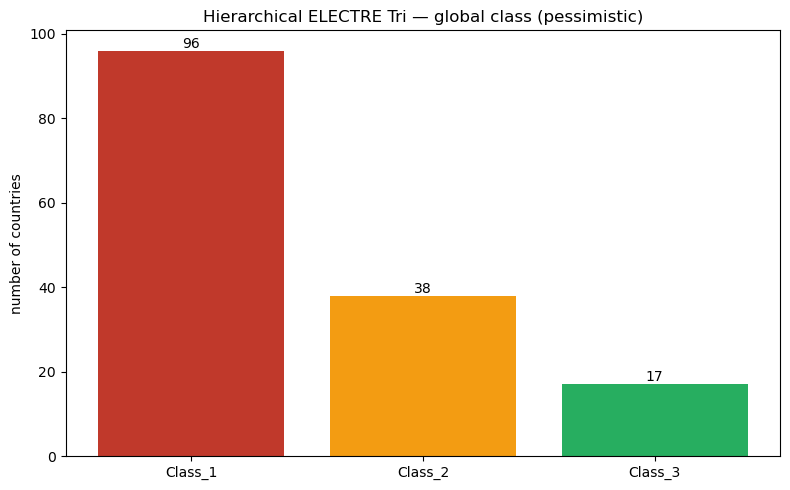

In [52]:
class_counts = res_pess["Freedom_and_Prosperity"].value_counts().reindex(categories, fill_value=0)
print("Distribution in the global class (Freedom_and_Prosperity):")
print(class_counts)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(class_counts.index, class_counts.values, color=["#c0392b", "#f39c12", "#27ae60"])
ax.set_ylabel("number of countries")
ax.set_title("Hierarchical ELECTRE Tri — global class (pessimistic)")
for x, y in zip(class_counts.index, class_counts.values):
    ax.text(x, y, str(y), ha="center", va="bottom")
plt.tight_layout()
plt.show()


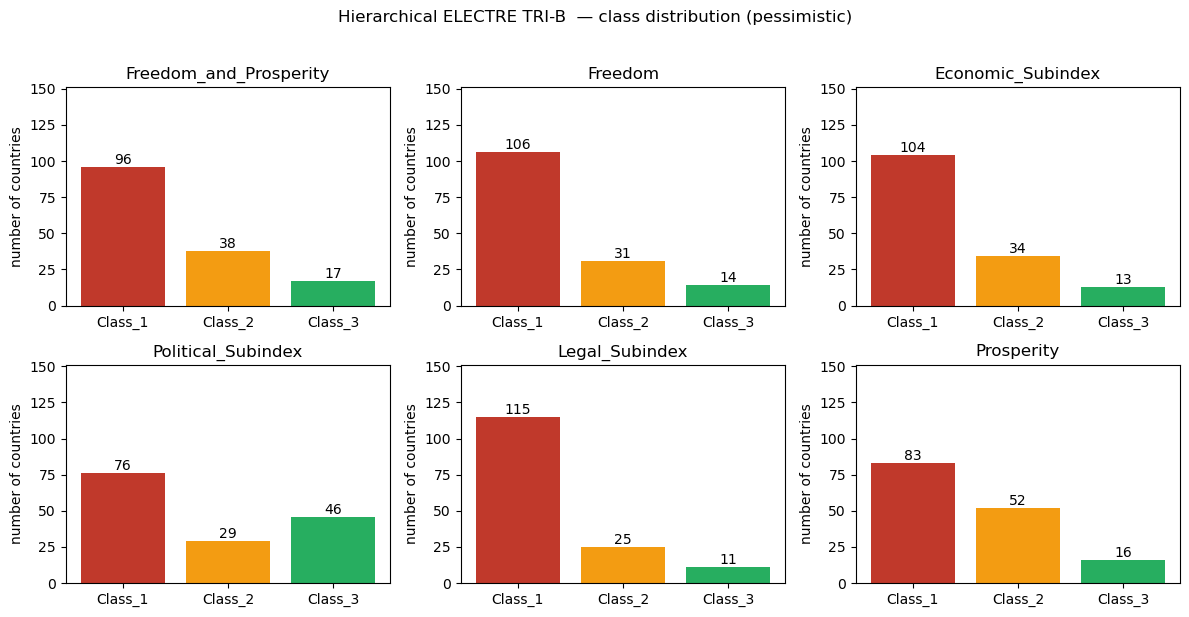

In [53]:
nodes = list(lambdas.keys())  # root + dimensions + subdimensions
colors = {"Class_1": "#c0392b", "Class_2": "#f39c12", "Class_3": "#27ae60"}

ncols = 3
nrows = math.ceil(len(nodes) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for ax, node in zip(axes, nodes):
    class_counts = res_pess[node].value_counts().reindex(categories, fill_value=0)
    ax.bar(class_counts.index, class_counts.values, color=[colors[c] for c in class_counts.index])
    ax.set_title(node)
    ax.set_ylabel("number of countries")
    ax.set_ylim(0, len(df))
    for x, y in zip(class_counts.index, class_counts.values):
        ax.text(x, y, str(y), ha="center", va="bottom")

# turn off the leftover subplots
for ax in axes[len(nodes):]:
    ax.axis("off")

fig.suptitle("Hierarchical ELECTRE TRI-B  — class distribution (pessimistic)",
             y=1.02)
plt.tight_layout()
plt.show()

In [54]:
_ = country_hierarchy("Brazil", Root, df, res_pess)

Country: Brazil
Freedom_and_Prosperity                                  -> Class_2
  Freedom                                               -> Class_1
    Economic_Subindex                                   -> Class_1
      Proper_Rights                                        (value = 61.94)
      Trade_Freedom                                        (value = 79.28)
      Investm_Freedom                                      (value = 40.00)
      Womens_Economic_Freedom                              (value = 85.00)
    Political_Subindex                                  -> Class_3
      PF_Elections                                         (value = 94.83)
      Civil_Liberties                                      (value = 80.95)
      Political_Rights                                     (value = 91.00)
      Legislative_Constraints_on_the_Executive             (value = 93.60)
    Legal_Subindex                                      -> Class_1
      Clarity_of_the_Law                         

# SMAA-TRI

## Fixed weights

In [56]:
N_SIM = 100          
SEED = 42            

categories = ["Class_1", "Class_2", "Class_3"]  # Class_3 is the best

rng = np.random.default_rng(SEED)
nodes = list(lambdas.keys())
alt_dicts = {name: df.loc[name].to_dict() for name in df.index}

counts = {c: {n: Counter() for n in nodes} for c in df.index}
params_fixed_w = []

for _ in range(N_SIM):
    q_s  = {lf: rng.uniform(3, 5)  for lf in leaves}
    p_s  = {lf: rng.uniform(5, 7)  for lf in leaves}
    v_s  = {lf: rng.uniform(30, 50) for lf in leaves}
    b1_s = {lf: rng.uniform(60, 70) for lf in leaves}
    b2_s = {lf: rng.uniform(80, 90) for lf in leaves}
    model.q, model.p, model.v = q_s, p_s, v_s
    model.profiles = {"b1": b1_s, "b2": b2_s}
    params_fixed_w.append({"q": q_s, "p": p_s, "v": v_s, "b1": b1_s, "b2": b2_s})

    for name, alt in alt_dicts.items():
        assigned = model.assign_all_nodes(alt, procedure="pessimistic")
        for n in nodes:
            counts[name][n][assigned[n]] += 1

params_fixed_w_df = params_to_df(params_fixed_w)
print(f"Simulation finished: {N_SIM} iterations.")
print(f"Parameters stored in 'params_fixed_w' (list of dicts) and "
      f"'params_fixed_w_df' {params_fixed_w_df.shape}.")

params_fixed_w_df

Simulation finished: 100 iterations.
Parameters stored in 'params_fixed_w' (list of dicts) and 'params_fixed_w_df' (100, 95).


param                 q                                                        \
id        Proper_Rights Trade_Freedom Investm_Freedom Womens_Economic_Freedom   
iteration                                                                       
0              4.547912      3.877757        4.717196                4.394736   
1              4.260565      3.723625        3.175300                3.236012   
2              4.873626      3.481941        3.245516                4.662225   
3              3.832525      3.098508        3.747228                4.047506   
4              4.105986      4.872280        4.560603                3.958739   
...                 ...           ...             ...                     ...   
95             4.048018      4.521861        4.653964                3.046445   
96             4.218400      4.920041        4.744335                3.697480   
97             4.487911      4.962791        4.985636                4.568395   
98             3.453647      4.120426        3.508055                4.142713   
99             4.220989      3.979961        3.253323                4.403858   

param                                                    \
id        PF_Elections Civil_Liberties Political_Rights   
iteration                                                 
0             3.188355        4.951245         4.522279   
1             4.923795        4.817161         4.399414   
2             3.306569        3.358537         4.198766   
3             3.203344        4.666917         3.103924   
4             3.752719        4.973263         4.435520   
...                ...             ...              ...   
95            3.158264        3.672935         4.835227   
96            4.719813        4.916956         3.514394   
97            3.324368        4.955419         3.655627   
98            3.343444        4.882465         4.773835   
99            4.291997        3.684497         3.712646   

param                                                                  \
id        Legislative_Constraints_on_the_Executive Clarity_of_the_Law   
iteration                                                               
0                                         4.572129           3.256227   
1                                         3.531740           4.938353   
2                                         4.749124           3.392869   
3                                         4.849684           3.198226   
4                                         4.902389           3.236957   
...                                            ...                ...   
95                                        3.796547           4.775024   
96                                        4.220418           3.563608   
97                                        3.667239           4.374674   
98                                        3.673836           4.553326   
99                                        3.493445           4.923831   

param                                              ...  \
id        Judicial_Independence_and_Effectiveness  ...   
iteration                                          ...   
0                                        3.900772  ...   
1                                        4.557502  ...   
2                                        3.620647  ...   
3                                        4.687150  ...   
4                                        4.701067  ...   
...                                           ...  ...   
95                                       3.924868  ...   
96                                       4.299135  ...   
97                                       3.098098  ...   
98                                       3.191008  ...   
99                                       4.720403  ...   

param                                          b2                             \
id        Judicial_Independence_and_Effectiveness Bureaucracy_and_Corruption   
iteration                                 

## Class acceptability indices (SMAA-TRI)

In [ ]:
accept = {}
for name in df.index:
    row = {}
    for n in nodes:
        total = sum(counts[name][n].values())  
        for c in categories:
            row[(n, c)] = counts[name][n][c] / total
    accept[name] = row

acceptability = pd.DataFrame(accept).T
acceptability.columns = pd.MultiIndex.from_tuples(acceptability.columns, names=["node", "class"])
acceptability = acceptability[[(n, c) for n in nodes for c in categories]]

acceptability

node                 Freedom_and_Prosperity                 Freedom          \
class                               Class_1 Class_2 Class_3 Class_1 Class_2   
Angola                                 1.00    0.00     0.0    1.00    0.00   
Albania                                0.06    0.94     0.0    0.86    0.14   
United Arab Emirates                   1.00    0.00     0.0    1.00    0.00   
Argentina                              0.09    0.91     0.0    1.00    0.00   
Armenia                                0.26    0.74     0.0    1.00    0.00   
...                                     ...     ...     ...     ...     ...   
Vietnam                                1.00    0.00     0.0    1.00    0.00   
Yemen                                  1.00    0.00     0.0    1.00    0.00   
South Africa                           1.00    0.00     0.0    1.00    0.00   
Zambia                                 1.00    0.00     0.0    1.00    0.00   
Zimbabwe                               1.00    0.00     0.0    1.00    0.00   

node                         Economic_Subindex                  \
class                Class_3           Class_1 Class_2 Class_3   
Angola                   0.0              1.00    0.00     0.0   
Albania                  0.0              1.00    0.00     0.0   
United Arab Emirates     0.0              0.95    0.05     0.0   
Argentina                0.0              1.00    0.00     0.0   
Armenia                  0.0              0.55    0.45     0.0   
...                      ...               ...     ...     ...   
Vietnam                  0.0              0.98    0.02     0.0   
Yemen                    0.0              1.00    0.00     0.0   
South Africa             0.0              1.00    0.00     0.0   
Zambia                   0.0              1.00    0.00     0.0   
Zimbabwe                 0.0              1.00    0.00     0.0   

node                 Political_Subindex                 Legal_Subindex  \
class                           Class_1 Class_2 Class_3        Class_1   
Angola                              1.0    0.00    0.00            1.0   
Albania                             0.0    1.00    0.00            1.0   
United Arab Emirates                1.0    0.00    0.00            1.0   
Argentina                           0.0    0.25    0.75            1.0   
Armenia                             0.0    1.00    0.00            1.0   
...                                 ...     ...     ...            ...   
Vietnam                             1.0    0.00    0.00            1.0   
Yemen                               1.0    0.00    0.00            1.0   
South Africa                        0.0    0.00    1.00            1.0   
Zambia                              0.0    0.94    0.06            1.0   
Zimbabwe                            1.0    0.00    0.00            1.0   

node                                 Prosperity                  
class                Class_2 Class_3    Class_1 Class_2 Class_3  
Angola                   0.0     0.0       1.00    0.00     0.0  
Albania                  0.0     0.0       0.05    0.95     0.0  
United Arab Emirates     0.0     0.0       0.01    0.99     0.0  
Argentina                0.0     0.0       0.00    1.00     0.0  
Armenia                  0.0     0.0       0.00    1.00     0.0  
...                      ...     ...        ...     ...     ...  
Vietnam                  0.0     0.0       0.48    0.52     0.0  
Yemen                    0.0     0.0       1.00    0.00     0.0  
South Africa             0.0     0.0       1.00    0.00     0.0  
Zambia                   0.0     0.0       1.00    0.00     0.0  
Zimbabwe                 0.0     0.0       1.00    0.00     0.0  

[151 rows x 18 columns]

In [58]:
class_acceptability_smaa(acceptability, categories, "Freedom_and_Prosperity").round(3)

class,Class_1,Class_2,Class_3
Belgium,0.0,0.0,1.0
Switzerland,0.0,0.0,1.0
Denmark,0.0,0.0,1.0
Finland,0.0,0.0,1.0
Ireland,0.0,0.0,1.0
...,...,...,...
Vietnam,1.0,0.0,0.0
Yemen,1.0,0.0,0.0
South Africa,1.0,0.0,0.0
Zambia,1.0,0.0,0.0


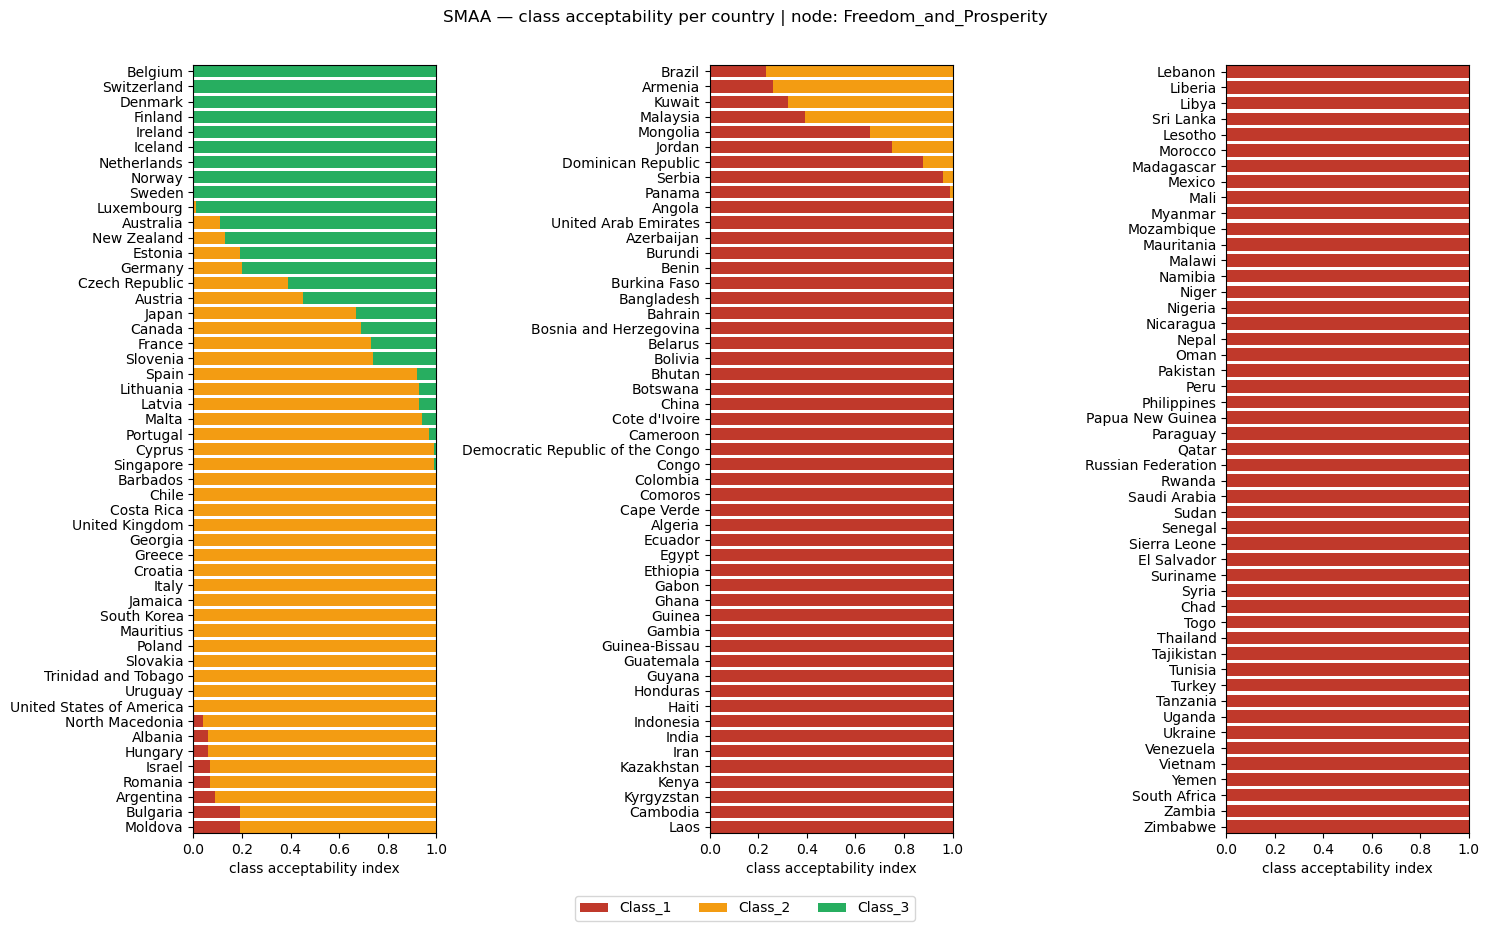

In [59]:
colors = {"Class_1": "#c0392b", "Class_2": "#f39c12", "Class_3": "#27ae60"}

plot_acceptability_smaa(acceptability, categories, colors, "Freedom_and_Prosperity")

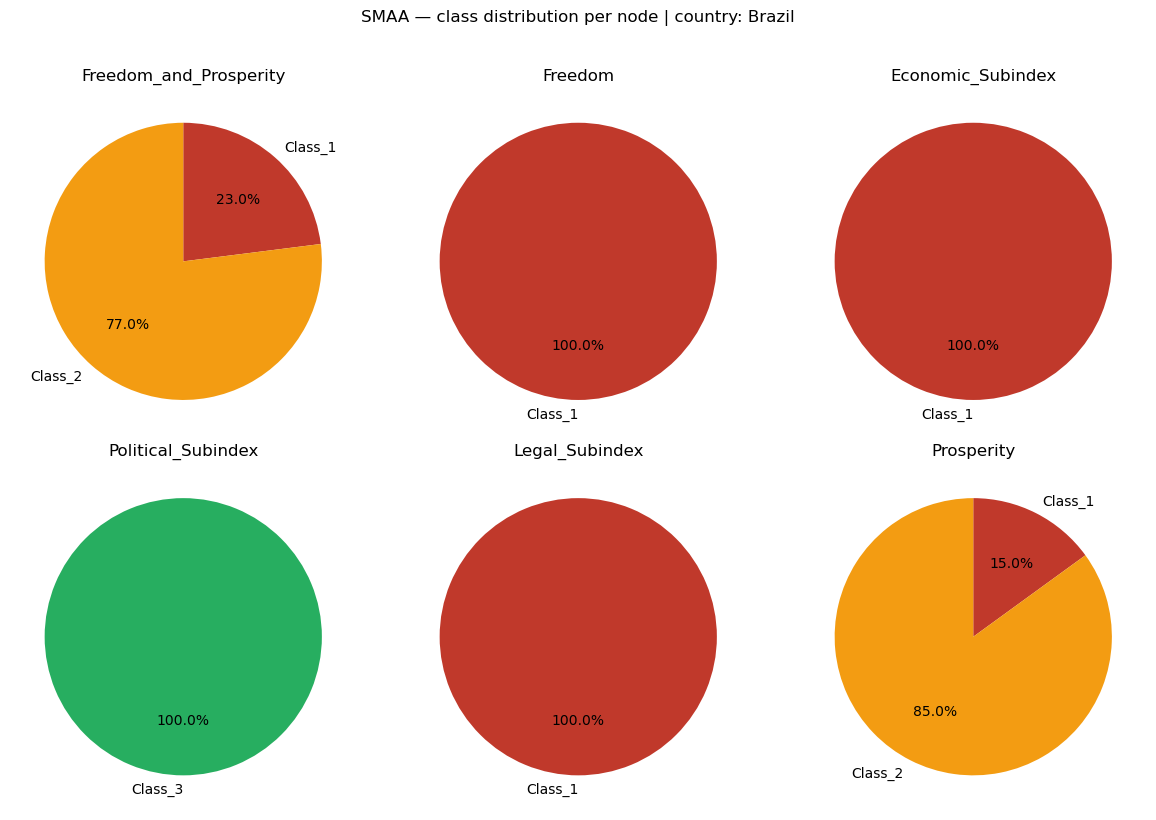

In [60]:
plot_country_pies_smaa(acceptability, nodes, categories, colors, "Brazil")

# SMAA-TRI

## Varying weights

In [ ]:
# Varying-weights version
N_SIM = 1000          # number of Monte Carlo iterations
SEED = 42             # reproducibility
rng = np.random.default_rng(SEED)
nodes = list(lambdas.keys())
alt_dicts = {name: df.loc[name].to_dict() for name in df.index}
def sample_weights(node, weight, rng, out=None):
    """Split `weight` among the children with Dirichlet(1,...,1) (uniform on the
    simplex) and recurse down to the leaves. Preserves the hierarchy: on average
    it keeps each dimension's expected weight (Freedom≈0.5, etc.)."""
    if out is None:
        out = {}
    if node.is_leaf():
        out[node.leaf_id] = weight
        return out
    fracs = rng.dirichlet(np.ones(len(node.children)))
    for child, f in zip(node.children, fracs):
        sample_weights(child, weight * f, rng, out)
    return out

# counts_w[country][node] -> Counter({class: number of times})
counts_w = {c: {n: Counter() for n in nodes} for c in df.index}
# store the parameters sampled in each iteration (for later inspection)
params_varying_w = []

for _ in range(N_SIM):
    w   = sample_weights(Root, 1.0, rng)
    lam = compute_lambdas(Root, w, lambda_frac)
    q_s  = {lf: rng.uniform(3, 5)  for lf in leaves}
    p_s  = {lf: rng.uniform(5, 7)  for lf in leaves}
    v_s  = {lf: rng.uniform(30, 50) for lf in leaves}
    b1_s = {lf: rng.uniform(60, 70) for lf in leaves}
    b2_s = {lf: rng.uniform(80, 90) for lf in leaves}

    model.weights, model.lambdas = w, lam
    model.q, model.p, model.v = q_s, p_s, v_s
    model.profiles = {"b1": b1_s, "b2": b2_s}

    params_varying_w.append(
        {"weights": w, "lambdas": lam,
         "q": q_s, "p": p_s, "v": v_s, "b1": b1_s, "b2": b2_s}
    )

    for name, alt in alt_dicts.items():
        assigned = model.assign_all_nodes(alt, procedure="pessimistic")
        for n in nodes:
            counts_w[name][n][assigned[n]] += 1

# restore the base-scenario parameters in the model
model.weights, model.lambdas = weights, lambdas
model.q, model.p, model.v, model.profiles = q, p, v, profiles

params_varying_w_df = params_to_df(params_varying_w)
print(f"Simulation finished: {N_SIM} iterations.")
params_varying_w_df

Simulation finished: 1000 iterations.


param           weights                                                        \
id        Proper_Rights Trade_Freedom Investm_Freedom Womens_Economic_Freedom   
iteration                                                                       
0              0.105283      0.102189        0.226437                0.005747   
1              0.001831      0.023741        0.025209                0.007635   
2              0.098365      0.124264        0.041385                0.105765   
3              0.084299      0.045570        0.305626                0.035478   
4              0.030891      0.053992        0.044655                0.002995   
...                 ...           ...             ...                     ...   
995            0.003575      0.012280        0.006234                0.005709   
996            0.013843      0.014787        0.262429                0.128754   
997            0.002050      0.010609        0.056734                0.103798   
998            0.000398      0.000448        0.005647                0.002236   
999            0.153355      0.038133        0.137687                0.064891   

param                                                    \
id        PF_Elections Civil_Liberties Political_Rights   
iteration                                                 
0             0.013711        0.000923         0.014267   
1             0.000144        0.008562         0.002534   
2             0.041455        0.020573         0.009981   
3             0.055335        0.098709         0.005814   
4             0.017167        0.016563         0.004910   
...                ...             ...              ...   
995           0.004841        0.117290         0.000517   
996           0.016035        0.061717         0.019266   
997           0.053995        0.009661         0.059555   
998           0.003068        0.009004         0.000641   
999           0.145993        0.015266         0.021407   

param                                                                  \
id        Legislative_Constraints_on_the_Executive Clarity_of_the_Law   
iteration                                                               
0                                         0.022682           0.002829   
1                                         0.004668           0.001970   
2                                         0.056483           0.038834   
3                                         0.041231           0.020005   
4                                         0.029222           0.001135   
...                                            ...                ...   
995                                       0.022256           0.001422   
996                                       0.017812           0.014164   
997                                       0.174440           0.077110   
998                                       0.001404           0.000076   
999                                       0.036619           0.013385   

param                                              ...  \
id        Judicial_Independence_and_Effectiveness  ...   
iteration                                          ...   
0                                        0.009007  ...   
1                                        0.009360  ...   
2                                        0.048430  ...   
3                                        0.003957  ...   
4                                        0.028792  ...   
...                                           ...  ...   
995                                      0.039174  ...   
996                                      0.011141  ...   
997                                      0.020220  ...   
998                                      0.000021  ...   
999                                      0.080291  ...   

param                                          b2                             \
id        Judicial_Independence_and_Effectiveness Bureaucracy_and_Corruption   
iteration                                 

In [63]:
accept_w = {}
for name in df.index:
    row = {}
    for n in nodes:
        total = sum(counts_w[name][n].values())  
        for c in categories:
            row[(n, c)] = counts_w[name][n][c] / total
    accept_w[name] = row

acceptability_w = pd.DataFrame(accept_w).T
acceptability_w.columns = pd.MultiIndex.from_tuples(acceptability_w.columns, names=["node", "class"])
acceptability_w = acceptability_w[[(n, c) for n in nodes for c in categories]]

acceptability_w

node                 Freedom_and_Prosperity                 Freedom          \
class                               Class_1 Class_2 Class_3 Class_1 Class_2   
Angola                                1.000   0.000     0.0   1.000   0.000   
Albania                               0.273   0.727     0.0   0.723   0.277   
United Arab Emirates                  1.000   0.000     0.0   1.000   0.000   
Argentina                             0.263   0.737     0.0   0.871   0.129   
Armenia                               0.375   0.625     0.0   0.864   0.136   
...                                     ...     ...     ...     ...     ...   
Vietnam                               1.000   0.000     0.0   1.000   0.000   
Yemen                                 1.000   0.000     0.0   1.000   0.000   
South Africa                          1.000   0.000     0.0   0.872   0.128   
Zambia                                0.990   0.010     0.0   0.943   0.057   
Zimbabwe                              1.000   0.000     0.0   1.000   0.000   

node                         Economic_Subindex                  \
class                Class_3           Class_1 Class_2 Class_3   
Angola                   0.0             1.000   0.000   0.000   
Albania                  0.0             0.949   0.051   0.000   
United Arab Emirates     0.0             0.744   0.255   0.001   
Argentina                0.0             0.993   0.007   0.000   
Armenia                  0.0             0.561   0.439   0.000   
...                      ...               ...     ...     ...   
Vietnam                  0.0             0.842   0.158   0.000   
Yemen                    0.0             1.000   0.000   0.000   
South Africa             0.0             0.991   0.009   0.000   
Zambia                   0.0             0.992   0.008   0.000   
Zimbabwe                 0.0             1.000   0.000   0.000   

node                 Political_Subindex                 Legal_Subindex  \
class                           Class_1 Class_2 Class_3        Class_1   
Angola                             1.00   0.000   0.000          1.000   
Albania                            0.00   0.967   0.033          0.922   
United Arab Emirates               1.00   0.000   0.000          0.956   
Argentina                          0.00   0.307   0.693          0.985   
Armenia                            0.16   0.823   0.017          0.999   
...                                 ...     ...     ...            ...   
Vietnam                            1.00   0.000   0.000          0.999   
Yemen                              1.00   0.000   0.000          1.000   
South Africa                       0.00   0.049   0.951          0.981   
Zambia                             0.00   0.848   0.152          0.998   
Zimbabwe                           1.00   0.000   0.000          1.000   

node                                 Prosperity                  
class                Class_2 Class_3    Class_1 Class_2 Class_3  
Angola                 0.000     0.0      0.998   0.002   0.000  
Albania                0.078     0.0      0.169   0.831   0.000  
United Arab Emirates   0.044     0.0      0.344   0.616   0.040  
Argentina              0.015     0.0      0.014   0.977   0.009  
Armenia                0.001     0.0      0.055   0.942   0.003  
...                      ...     ...        ...     ...     ...  
Vietnam                0.001     0.0      0.443   0.557   0.000  
Yemen                  0.000     0.0      1.000   0.000   0.000  
South Africa           0.019     0.0      1.000   0.000   0.000  
Zambia                 0.002     0.0      1.000   0.000   0.000  
Zimbabwe               0.000     0.0      0.999   0.001   0.000  

[151 rows x 18 columns]

In [64]:
class_acceptability_smaa(acceptability_w, categories, "Freedom_and_Prosperity").round(3)

class,Class_1,Class_2,Class_3
Ireland,0.0,0.026,0.974
Sweden,0.0,0.033,0.967
Denmark,0.0,0.043,0.957
Finland,0.0,0.049,0.951
Luxembourg,0.0,0.074,0.926
...,...,...,...
Venezuela,1.0,0.000,0.000
Vietnam,1.0,0.000,0.000
Yemen,1.0,0.000,0.000
South Africa,1.0,0.000,0.000


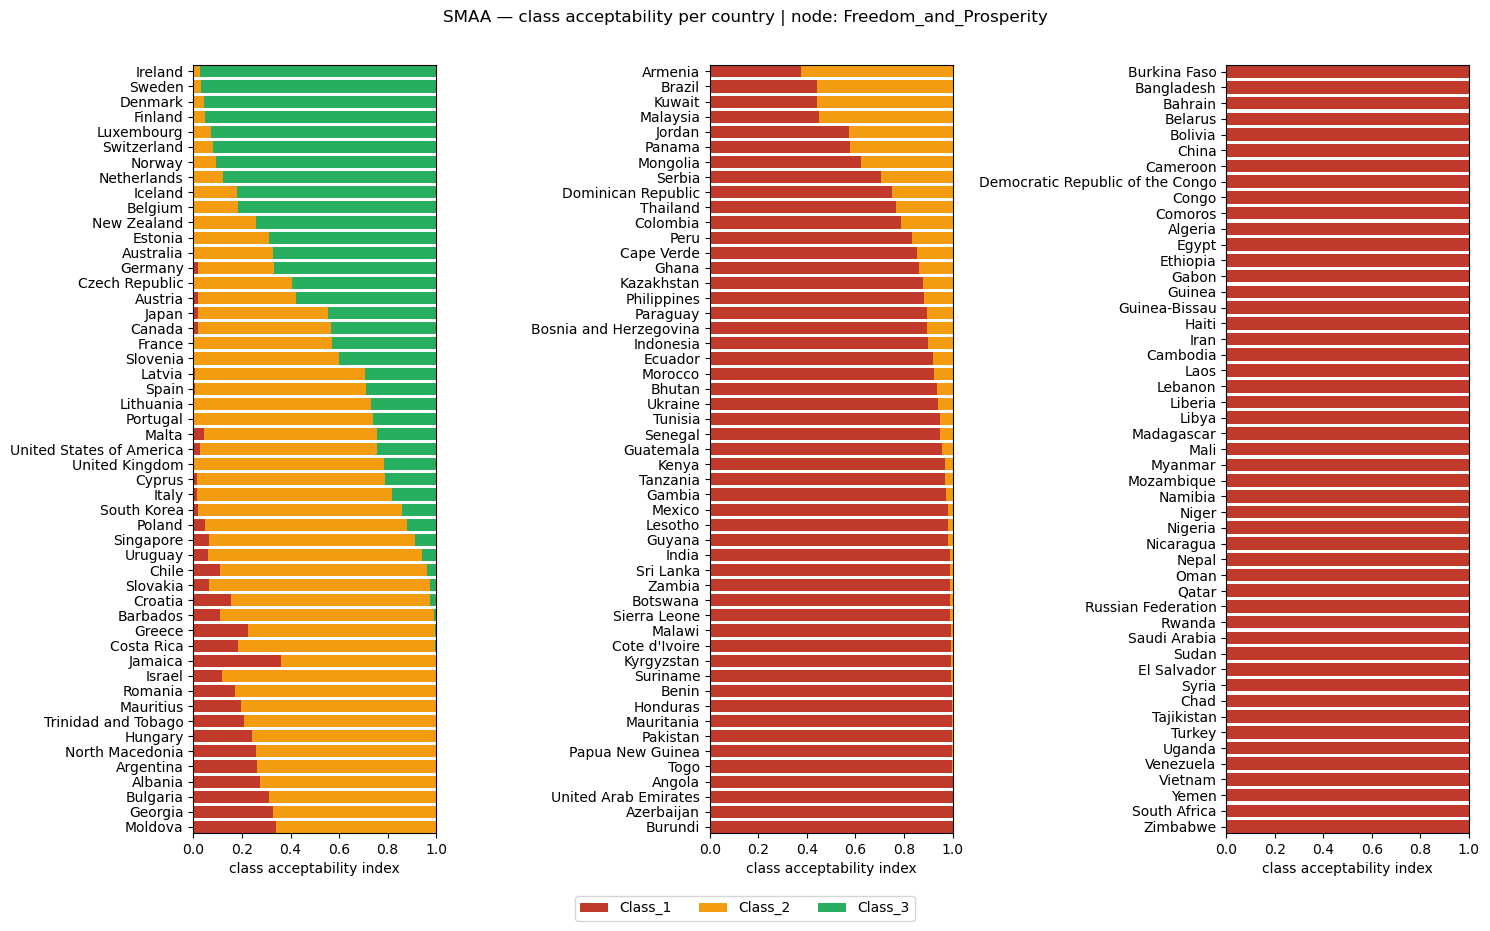

In [65]:
colors = {"Class_1": "#c0392b", "Class_2": "#f39c12", "Class_3": "#27ae60"}

plot_acceptability_smaa(acceptability_w, categories, colors, "Freedom_and_Prosperity")

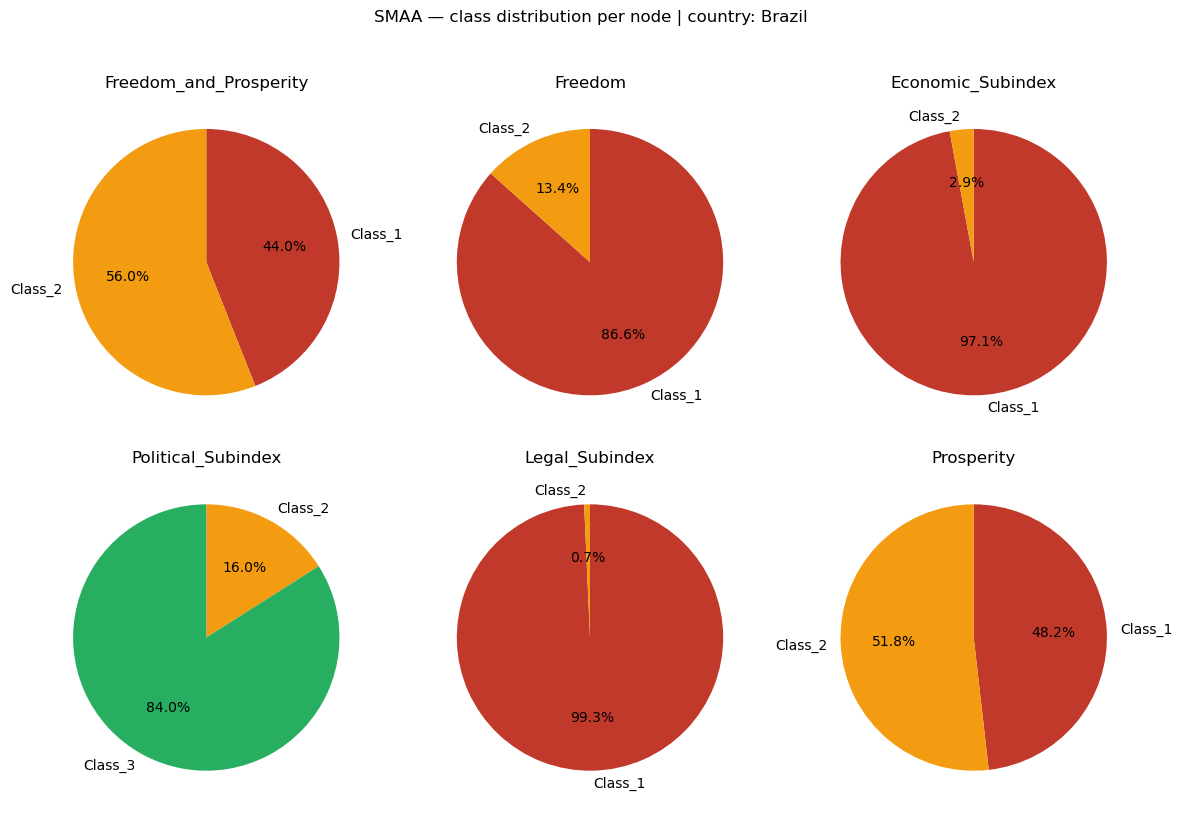

In [67]:
plot_country_pies_smaa(acceptability_w, nodes, categories, colors, "Brazil")